## **Assignment 1: Generative Deep Learning - 708.088 (SS26)**
**Authored by:** Ozan Özdenizci, Institute of Machine Learning and Neural Computation, TU Graz

**Assignment issued on:** March 19th, 2026 09:00 AM\
**Assignment deadline:** April 16th, 2026 09:00 AM

# Training a VQ-VAE with an Autoregressive Prior

Vector-quantized variational autoencoders (VQ-VAE) combined with an autoregressive prior over the discrete latent space.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1).float())
])

train_data = torchvision.datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_data = torchvision.datasets.MNIST(root='data/', train=False, transform=transform, download=True)

train_data, val_data = torch.utils.data.random_split(train_data, [55000, 5000])

training_loader = DataLoader(train_data, batch_size=128, shuffle=True)# shuffle needed because digits might be ordered in training set
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

### Part (a): VQ-VAE architecture

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_latents):
        super(Encoder, self).__init__()
        self.num_latents = num_latents
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, num_latents * latent_dim)#sets the dimension of the encoded embeddings
        )

    def forward(self, x):
        #hidden_dim B ... batch size
        #num_latents L ... number of latent vectors
        #latent_dim D ... dimension of each latent vector

        h = self.net(x) # [B , L*D] passes input through encoder to get latent embeddings
        return h.reshape(x.shape[0], self.num_latents, self.latent_dim)# [B, L, D], sequences of latent vectors
        #retursn z_e

class Decoder(nn.Module):
    def __init__(self, latent_dim, num_latents, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(num_latents * latent_dim, hidden_dim), # [L*D, B]
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z_q):
        B, L, D = z_q.shape
        z_q_flat = z_q.reshape(B, L * D) #concatenates latent vectors
        return self.net(z_q_flat)
        #returns x_hat


class VectorQuantizer(nn.Module):
    def __init__(self, K, D, beta=0.25):
        super(VectorQuantizer, self).__init__()
        self.K = K          # number of codebook entries
        self.D = D          # dimensionality of each codebook entry
        self.beta = beta    # commitment loss weight

        # codebook with K entries each of dimension D
        self.embedding = nn.Embedding(K, D)
        self.embedding.weight.data.uniform_(-1.0 / K, 1.0 / K)

    def forward(self, z_e):
        B, L, D = z_e.shape   # batch size x latent sequence length x dim of codebook vectors

        # TODO: Compute distances between encoder outputs and codebook entries.
        # Find nearest codebook entry for each position
        # indices: codebook indices of shape (B, L)
        #combine all batches
        z_e_comb = z_e.reshape(B*L, D)
        # square_distances = z_e_comb.pow(2).sum(dim=1,keepdim = True)+ \
        #                     self.embedding.weight.pow(2).sum(dim=1)+ \
        #                     - 2* z_e_comb @ self.embedding.weight.t() # [B*L,K]
        # more compact, but root is taken first
        distances = torch.cdist(z_e_comb, self.embedding.weight).pow(2)# [B*L,K]
        indices = torch.argmin(distances,dim =1) # [B*L,1]

        # z_q: quantized output, should be same shape as z_e
        z_q = self.embedding(indices)
        z_q = z_q.reshape(B,L,D)

        # TODO: Compute VQ loss: codebook loss + beta * commitment losss
        # Codebook loss: moves codebook entries toward encoder outputs
        # Commitment loss: moves encoder outputs toward codebook entries
        cb_loss = F.mse_loss(z_e.detach(),z_q)
        comm_loss = F.mse_loss(z_e,z_q.detach())

        vq_loss = cb_loss + self.beta * comm_loss

        # Straight-through estimator: copy gradients from z_q to z_e
        z_q = z_e + (z_q - z_e).detach()

        return z_q, indices.reshape(B, L), vq_loss
        #resturns z_q

In [ ]:
class VQVAE(nn.Module):
    def __init__(self, encoder, decoder, quantizer):
        super(VQVAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.quantizer = quantizer

    def forward(self, x, reduction='avg'):
        z_e = self.encoder(x)
        z_q, indices, vq_loss = self.quantizer(z_e)
        x_recon = self.decoder(z_q)

        recon_loss = F.binary_cross_entropy(x_recon, x, reduction='none').sum(-1)

        if reduction == 'avg':
            return recon_loss.mean() + vq_loss
        elif reduction == 'sum':
            return recon_loss.sum() + vq_loss * x.shape[0]
        else:
            raise ValueError('reduction could be either `avg` or `sum`.')

    def encode_indices(self, x):
        with torch.no_grad():
            z_e = self.encoder(x) # each (flattened) image gets encoded into num_latent D-dimensional latent vectors
            _, indices, _ = self.quantizer(z_e) # each of the encoder latent vectors gets represented by closest codebook vector
        return indices

    def decode_indices(self, indices):
        with torch.no_grad():
            z_q = self.quantizer.embedding(indices)
            x_recon = self.decoder(z_q)
        return x_recon

In [ ]:
def evaluation_vqvae(test_loader, model):
    model.eval() #switch to evaluation, with fixed weights
    loss = 0.
    N = 0.
    for i, (test_batch, _) in enumerate(test_loader):
        loss_t = model.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N
    return loss


def training_vqvae(name, num_epochs, model, optimizer, training_loader, val_loader):
    loss_val = []

    for ep in range(num_epochs):
        model.train() #switch to training, learning weights
        for i, (batch, _) in enumerate(training_loader):
            loss = model.forward(batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_loss = evaluation_vqvae(val_loader, model)
        loss_val.append(val_loss)

        print(f'Epoch: {ep}, val loss={val_loss:.4f}')
        torch.save(model, name + '.model')

    return np.asarray(loss_val)

### Part (b): VQ-VAE initialization, hyperparameters and training

In [ ]:
data_dim = 784      # input dimension (28x28 images flattened)
image_dim = 28
hidden_dim = 128    # hidden layer dimensionality
num_latents = 8     # number of discrete latent positions (latent sequence length L)
D = 16              # dimensionality of each codebook entry
K = 16              # codebook size (number of entries)
beta = 0.25         # commitment loss weight
lr = 1e-3
num_epochs_vqvae = 20#100

result_dir = 'results/'
if not(os.path.exists(result_dir)):
    os.mkdir(result_dir)
name = 'vqvae'

encoder = Encoder(input_dim=data_dim, hidden_dim=hidden_dim, latent_dim=D, num_latents=num_latents)
decoder = Decoder(latent_dim=D, num_latents=num_latents, hidden_dim=hidden_dim, output_dim=data_dim)
quantizer = VectorQuantizer(K=K, D=D, beta=beta)
vqvae = VQVAE(encoder, decoder, quantizer)

optimizer_vqvae = torch.optim.Adam([p for p in vqvae.parameters() if p.requires_grad == True], lr=lr)

nll_vqvae = training_vqvae(name=result_dir + name, num_epochs=num_epochs_vqvae, model=vqvae,
                           optimizer=optimizer_vqvae, training_loader=training_loader,
                           val_loader=val_loader)
#don't hand over datasets for trianing and evaluation explicitly -> given as DataLoader object

Epoch: 17, val loss=579.2822
Epoch: 18, val loss=551.0580
Epoch: 19, val loss=533.4824


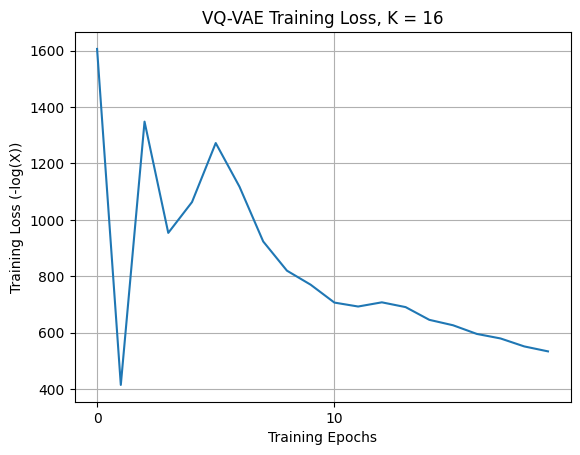

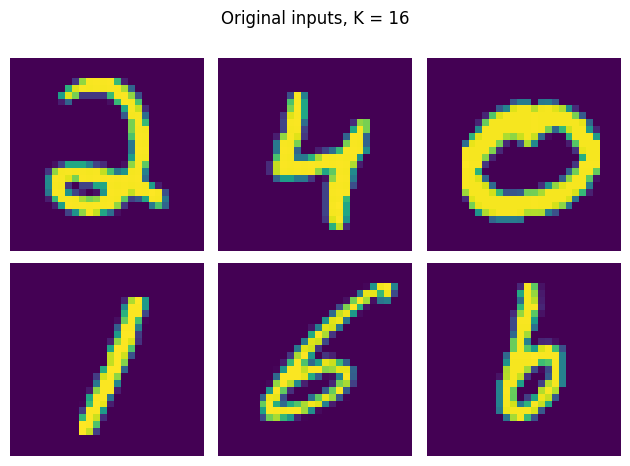

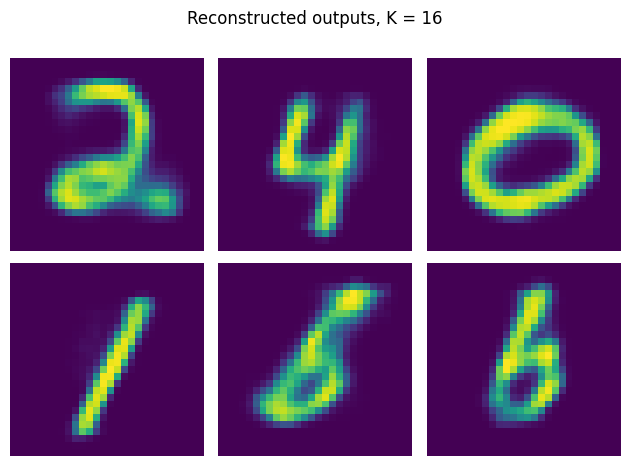

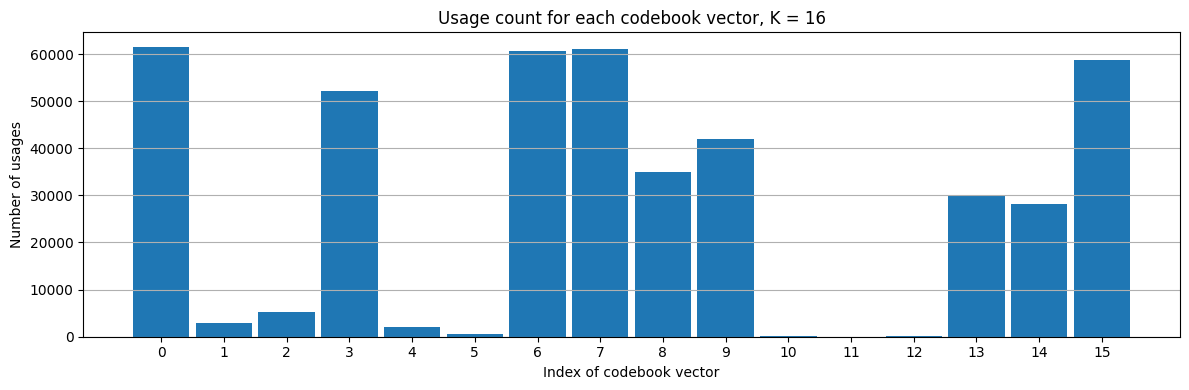

In [6]:
plot_folder = "./plots"

# TODO: Visualize the VQ-VAE model training process
fig = plt.figure()
plt.plot(nll_vqvae)
plt.xlabel("Training Epochs")
plt.ylabel("Training Loss (-log(X))")
plt.title(f"VQ-VAE Training Loss, K = {K}")
plt.xticks(np.arange(0,num_epochs_vqvae,10))
plt.grid()
plt.show()
fig.savefig(plot_folder+f"vqvae_train_loss_{K}.png")


# TODO: Visualize VQ-VAE model input versus reconstructions
num_samples = 6
full_training_data,classes = next(iter(training_loader))
input_samples = full_training_data[:num_samples]
quantized_samples, cb_indices,_ = vqvae.quantizer(vqvae.encoder(input_samples))
output_samples = vqvae.decoder(quantized_samples)

input_images = input_samples.reshape(-1,image_dim, image_dim)
reconstructed_images = output_samples.reshape(-1,image_dim, image_dim).detach().numpy()

fig, axs = plt.subplots(int(np.ceil(num_samples/3)),3,layout = "tight")
for i in range(int(np.ceil(num_samples/3))):
    for j in range(3):
        axs[i][j].imshow(input_images[i*3+j])
        axs[i][j].axis("off")
plt.suptitle(f"Original inputs, K = {K}")
plt.show()
fig.savefig(plot_folder+f"vqvae_original_{K}.png")

fig,axs = plt.subplots(int(np.ceil(num_samples/3)),3,layout = "tight")
for i in range(int(np.ceil(num_samples/3))):
    for j in range(3):
        axs[i][j].imshow(reconstructed_images[i*3+j])
        axs[i][j].axis("off")
plt.suptitle(f"Reconstructed outputs, K = {K}")
plt.show()
fig.savefig(plot_folder+f"vqvae_reconstructed_{K}.png")


# TODO: Visualize how many codebook entries are utilized across the training set.
train_indices = []
for batch, classes in training_loader:
    #each image in batch gets assigned num_latent codebook vectors, i.e. here: 8 indices between 0 and K-1
    train_indices.append(vqvae.encode_indices(batch).flatten())
train_indices = torch.cat(train_indices)

plt.figure(figsize =(12,4),layout = "tight")
plt.grid(axis = 'y')

num_bins = K # one per codebook vector
counts, labels, bars = plt.hist(train_indices,bins = np.arange(K+1),rwidth=0.9)
#plt.bar_label(bars)
plt.xlabel("Index of codebook vector")
plt.xticks(np.arange(K)+0.5)
plt.gca().set_xticklabels(np.arange(K))
plt.ylabel("Number of usages")
plt.title(f"Usage count for each codebook vector, K = {K}")
plt.show()
fig.savefig(plot_folder+f"used_code_book_vectors_{K}.png")


## Part (c): Autoregressive prior over the latent space

In [7]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, A=False):
        super(CausalConv1d, self).__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.A = A
        #ensuring, that padding is only added to the left(past values)
        self.padding = (kernel_size - 1) * dilation + A * 1

        self.conv1d = torch.nn.Conv1d(in_channels,
                                      out_channels,
                                      kernel_size,
                                      stride=1,
                                      padding=0,
                                      dilation=dilation,
                                      bias=True)

    def forward(self, x):
        x = torch.nn.functional.pad(x, (self.padding, 0))
        conv1d_out = self.conv1d(x)
        #A only needs to be true in the first layer, to not use the current position
        #in the following layers the current hidden state already only depends on z_i with i<l
        #in first position l = 0 we basically only use 0-padding for prediction
        # -> first pixel predicted from nothing, purely based on bias, no context
        # -> similar to starting sentence randomly
        if self.A:
            return conv1d_out[:, :, :-1]
        else:
            return conv1d_out


class ARPrior(nn.Module):
    def __init__(self, net, num_latents, K):
        super(ARPrior, self).__init__()
        self.net = net      # causal convolutional network
        self.num_latents = num_latents    # length of the discrete latent sequence (L)
        self.K = K          # codebook size (number of possible values per position)
        self.EPS = 1.e-5

    def forward(self, indices, reduction='avg'):
        if reduction == 'avg':
            return -(self.log_prob(indices).mean())
        elif reduction == 'sum':
            return -(self.log_prob(indices).sum())
        else:
            raise ValueError('reduction could be either `avg` or `sum`.')

    def log_prob(self, indices):
        p = self.f(indices) #log probability of codebook vectors, for each latent vector, in each batch
        #getting mask to select only p of the chosen indices
        indices_one_hot = F.one_hot(indices.long(), num_classes=self.K).float()
        #clamp avoids vanishing or exploding gradients
        log_p = indices_one_hot * torch.log(torch.clamp(p, self.EPS, 1. - self.EPS))
        #log prob of current latent state z, given all the previous latent states
        log_p = torch.sum(log_p, dim=-1).sum(-1)
        return log_p

    def f(self, indices):
        x = indices.float().unsqueeze(1)
        h = self.net(x) #passing latent vectors through convnet -> logits with dim. (B, K, L)
        h = h.permute(0, 2, 1)
        # (B, L, K) -> sequence of codebook vector probabilities for each latent state z_l
        return torch.softmax(h, dim=-1) #(B, L, K), transforms logits into probabilities

    def sample(self, batch_size):
        #generating initial zero-vector for codebook index sequences, that should describe z_l
        indices = torch.zeros((batch_size, self.num_latents), dtype=torch.long)
        #sequential generation of most likely codebook vectors, depending on previous z_l
        for l in range(self.num_latents):
            p = self.f(indices) #computes all positions, but only position l is used
            #draw random index according to learned probability distribution
            #computes all batches in parallel at position l !
            indices[:, l] = torch.multinomial(p[:, l, :], num_samples=1).squeeze(1)
        return indices

In [8]:
def evaluation_ar_prior(test_loader, vqvae, ar_prior):
    #predicts test image based on its ar_prior
    ar_prior.eval() #setting ar_prior model into evaluation mode
    loss = 0.
    N = 0.
    for i, (test_batch, _) in enumerate(test_loader):
        indices = vqvae.encode_indices(test_batch)
        #checking how well the ar_prior models the actual indices
        # (i.e. probability of obtaining these indices according to ar_prior)
        loss_t = ar_prior.forward(indices, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N
    return loss


def training_ar_prior(name, num_epochs, vqvae, ar_prior, optimizer, training_loader, val_loader):
    nll_val = []

    for ep in range(num_epochs):
        ar_prior.train()
        for i, (batch, _) in enumerate(training_loader):
            # TODO: Main training steps and loss computation
            # getting the encoded latent representations and codebook indices for each image
            # use frozen/pretrained vqvae for this
            b_indices = vqvae.encode_indices(batch)
            b_loss = ar_prior(b_indices) # NLL for indices

            #backpropagate loss
            optimizer.zero_grad()
            b_loss.backward()
            optimizer.step()


        val_loss = evaluation_ar_prior(val_loader, vqvae, ar_prior)
        nll_val.append(val_loss)
        print(f'Epoch: {ep}, val nll={val_loss:.4f}')

        # TODO: Generate and visualize 8 samples from the full model.
        # Sample index sequences from the AR prior, then decode with the frozen VQ-VAE decoder.
        # random sample generated by our learned prior
        num_samples = 8
        sample_indices = ar_prior.sample(num_samples)# (B, L)
        #decode
        sample_reconstructions = vqvae.decode_indices(sample_indices)# (B, image_dim*image_dim)
        sample_image_reconstructions = sample_reconstructions.reshape(-1,image_dim,image_dim)

        fig, axs = plt.subplots(int(np.ceil(num_samples/4)),4,layout = "tight")
        for i in range(int(np.ceil(num_samples/4))):
            for j in range(4):
                axs[i][j].imshow(sample_image_reconstructions[i*4+j])
                axs[i][j].axis("off")
        plt.suptitle(f"Generated outputs from AR prior, K = {K}")
        plt.show()
        fig.savefig(plot_folder+f"ar_prior_generations_{K}.png")

    return np.asarray(nll_val)

## Part (d): Autoregressive prior initialization, hyperparameters and training

Epoch: 0, val nll=14.7069


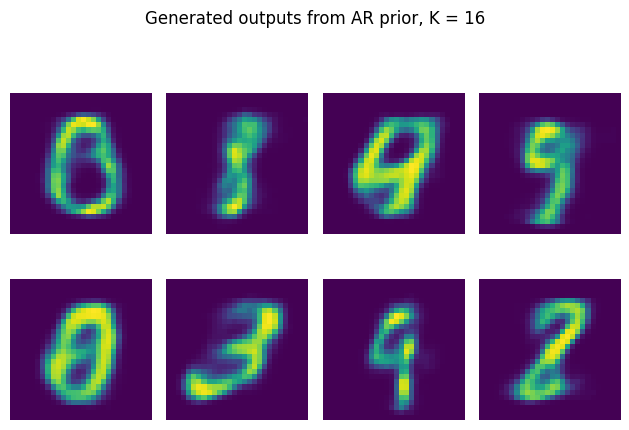

Epoch: 1, val nll=13.8557


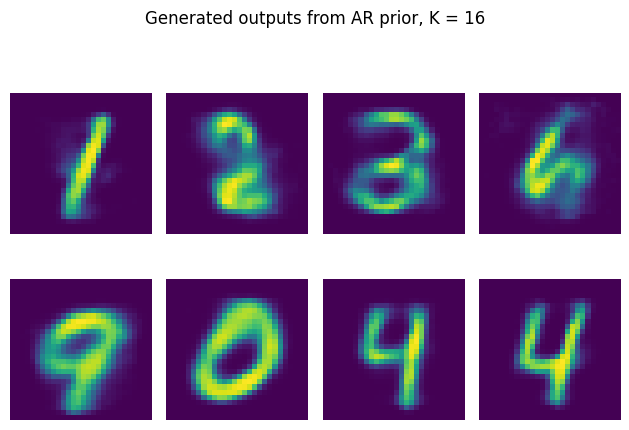

Epoch: 2, val nll=13.5209


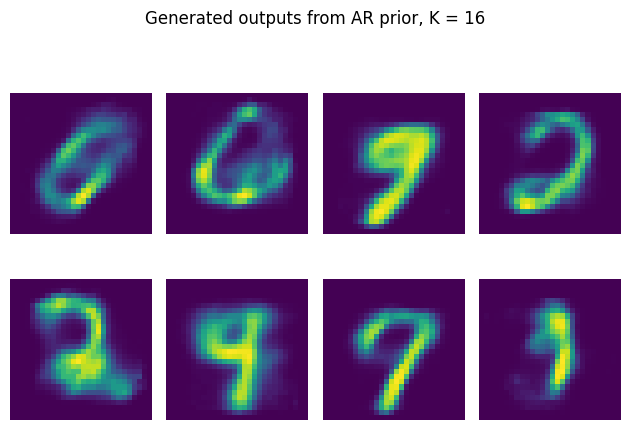

Epoch: 3, val nll=13.2470


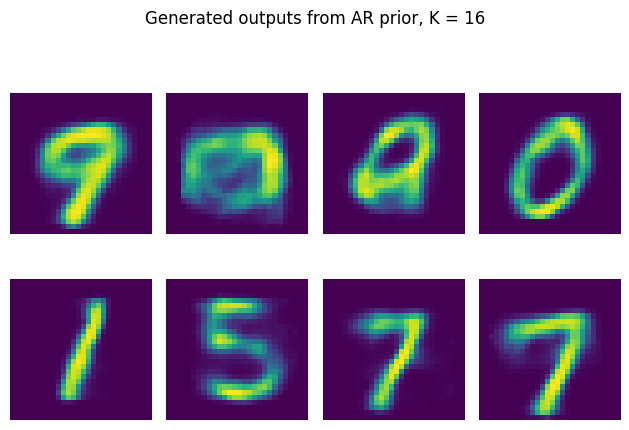

Epoch: 4, val nll=13.1359


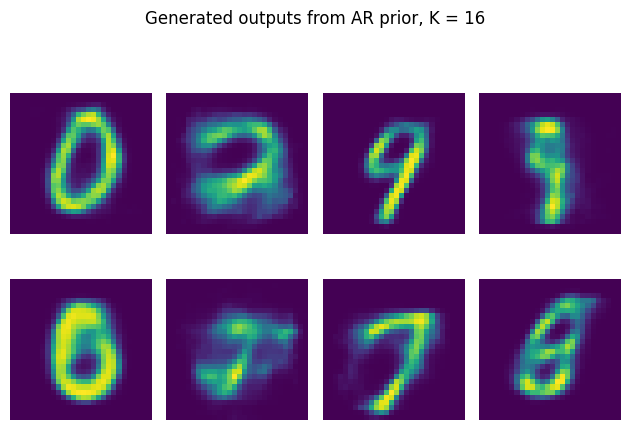

Epoch: 5, val nll=12.8733


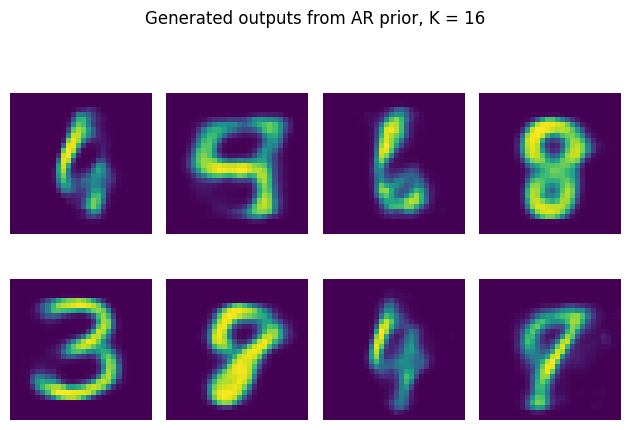

Epoch: 6, val nll=12.7990


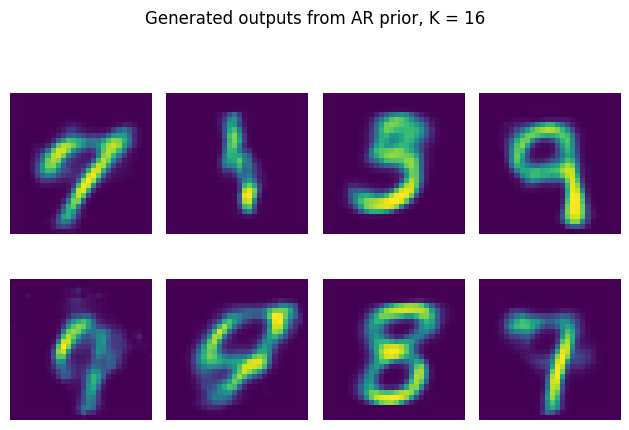

Epoch: 7, val nll=12.6997


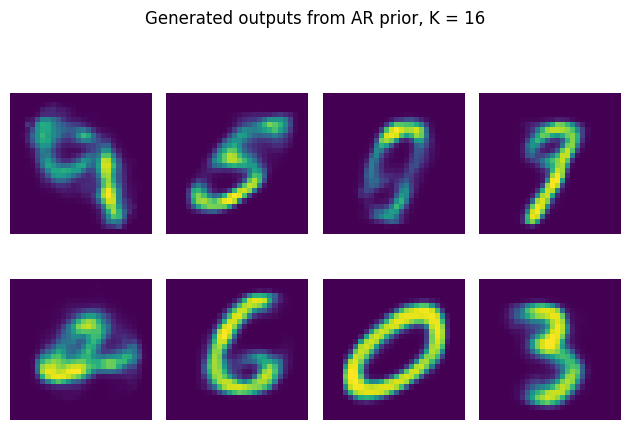

Epoch: 8, val nll=12.5909


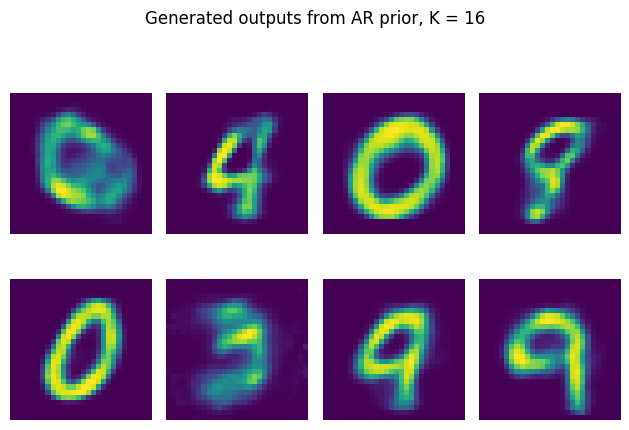

Epoch: 9, val nll=12.5612


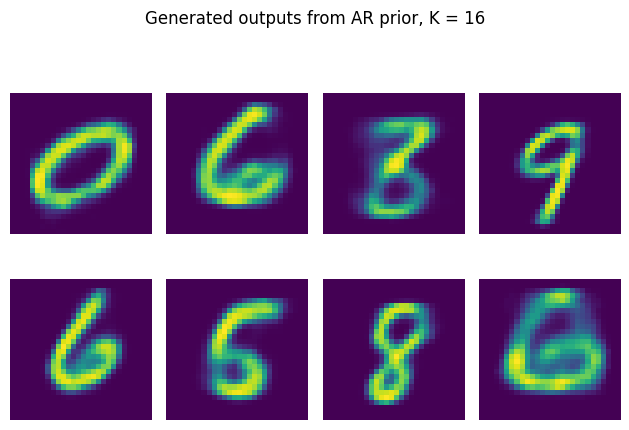

Epoch: 10, val nll=12.4144


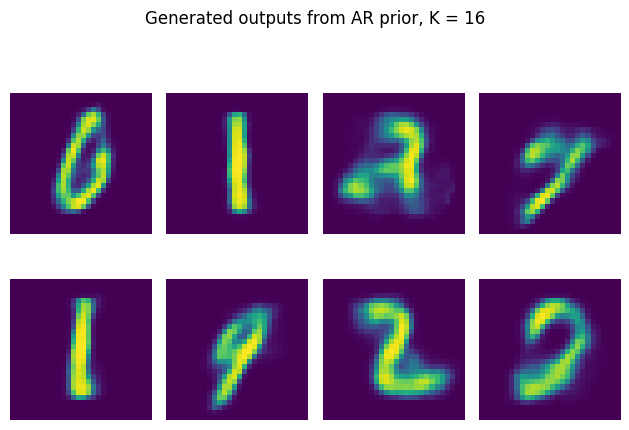

Epoch: 11, val nll=12.4308


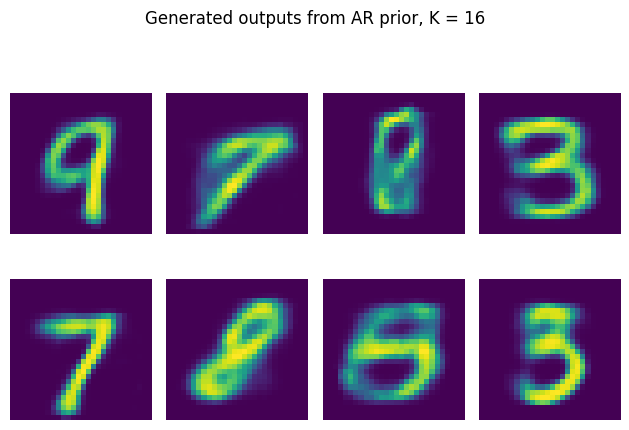

Epoch: 12, val nll=12.3724


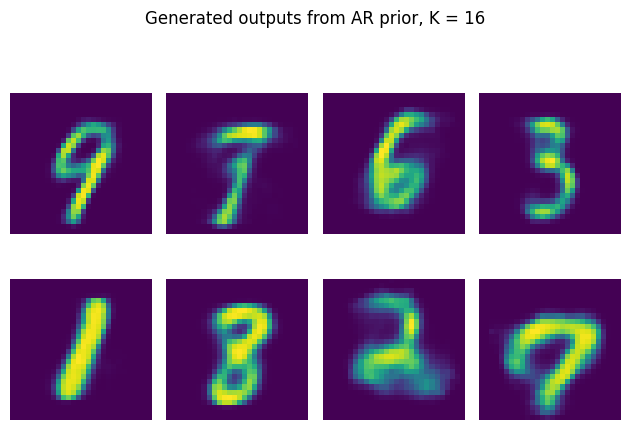

Epoch: 13, val nll=12.3164


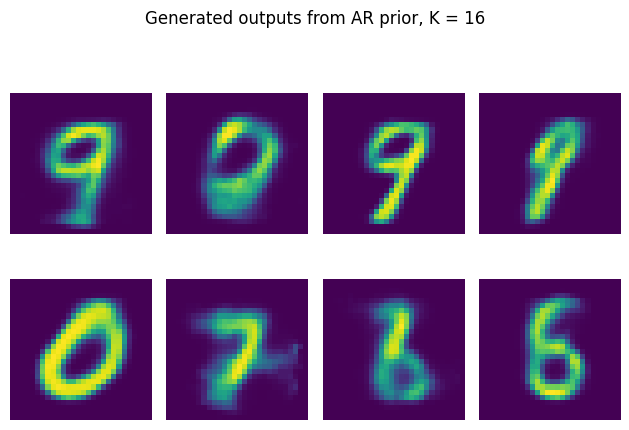

Epoch: 14, val nll=12.2967


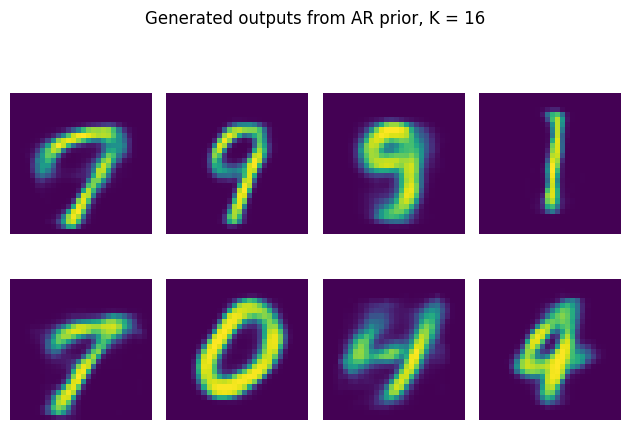

Epoch: 15, val nll=12.2819


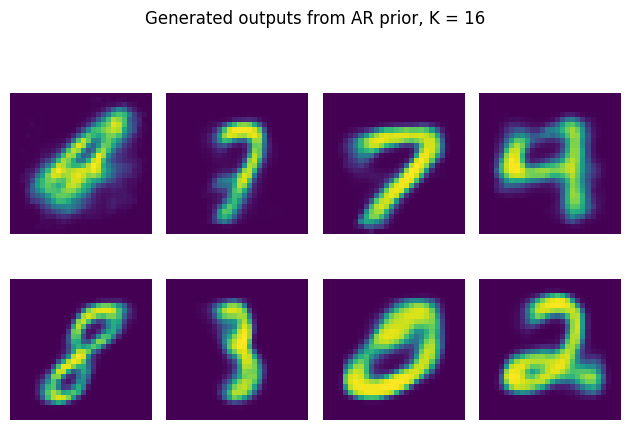

Epoch: 16, val nll=12.2876


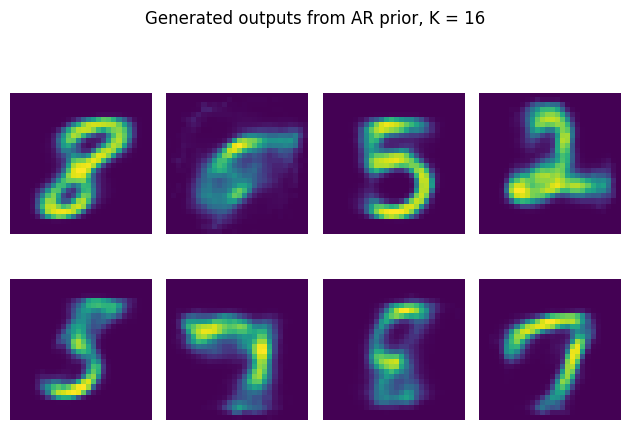

Epoch: 17, val nll=12.2092


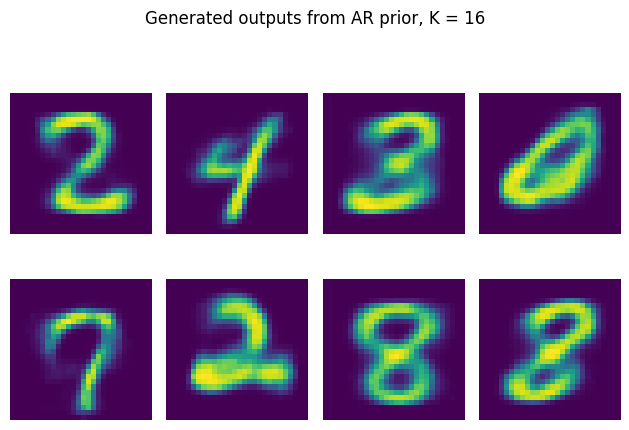

Epoch: 18, val nll=12.1803


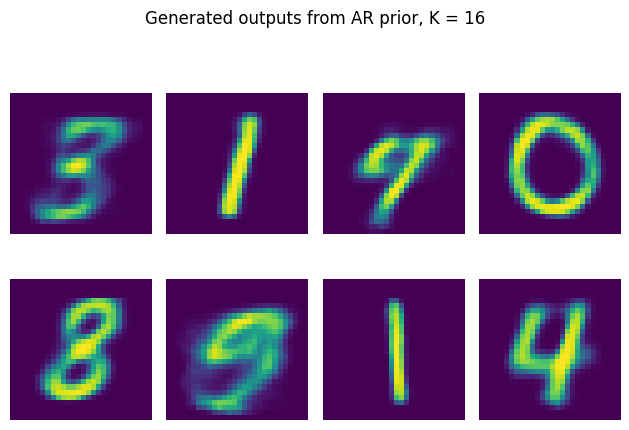

Epoch: 19, val nll=12.1216


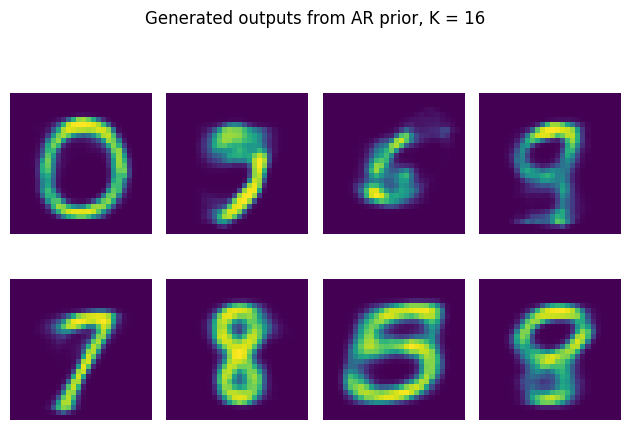

Epoch: 20, val nll=12.1194


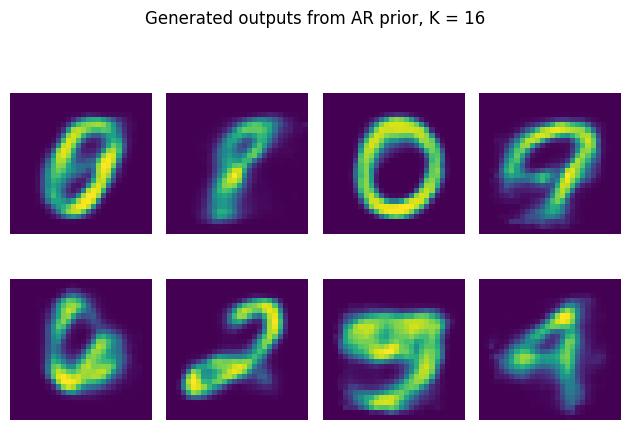

Epoch: 21, val nll=12.0935


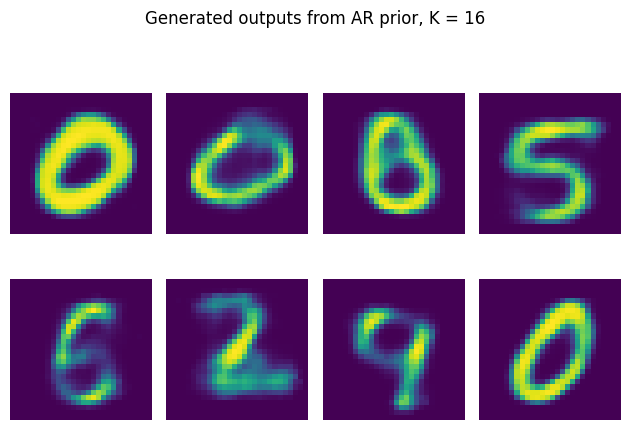

Epoch: 22, val nll=12.1124


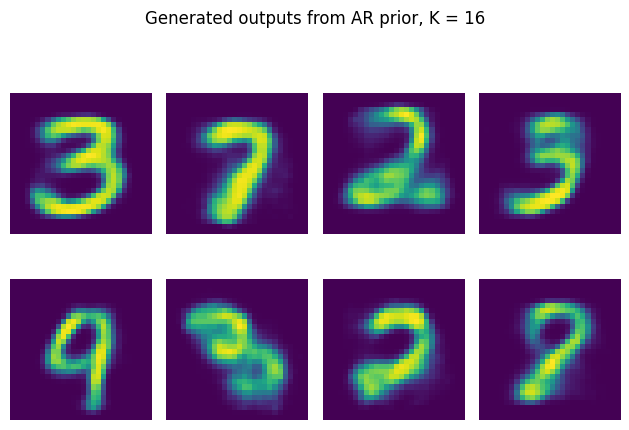

Epoch: 23, val nll=12.0728


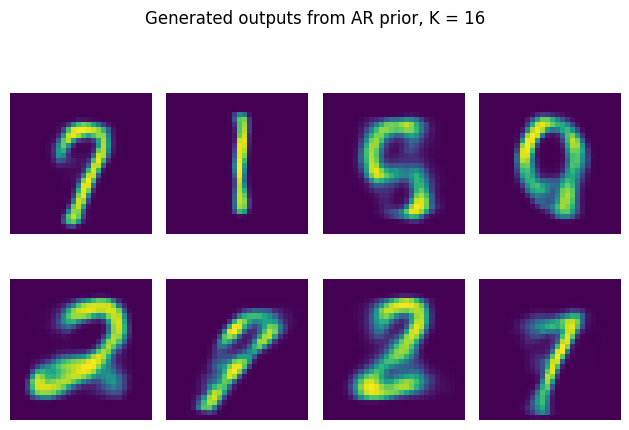

Epoch: 24, val nll=12.0069


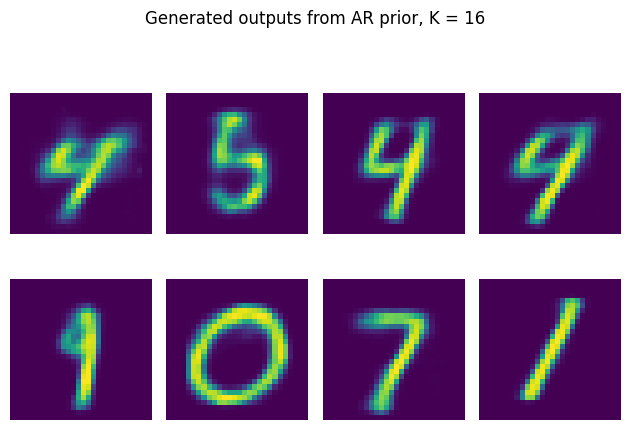

Epoch: 25, val nll=12.0360


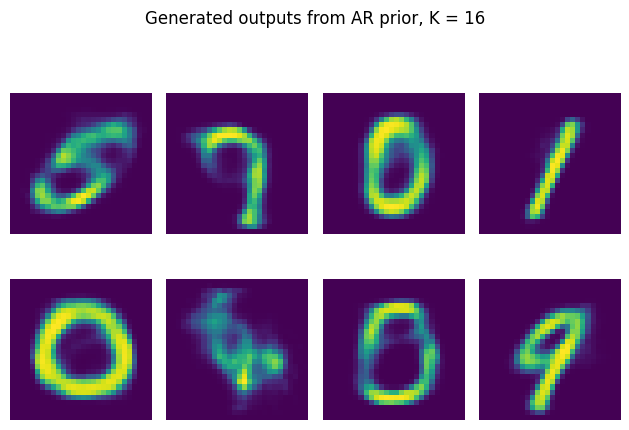

Epoch: 26, val nll=11.9932


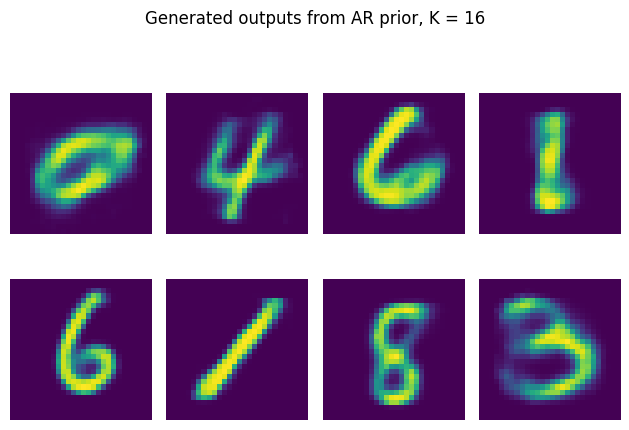

Epoch: 27, val nll=11.9835


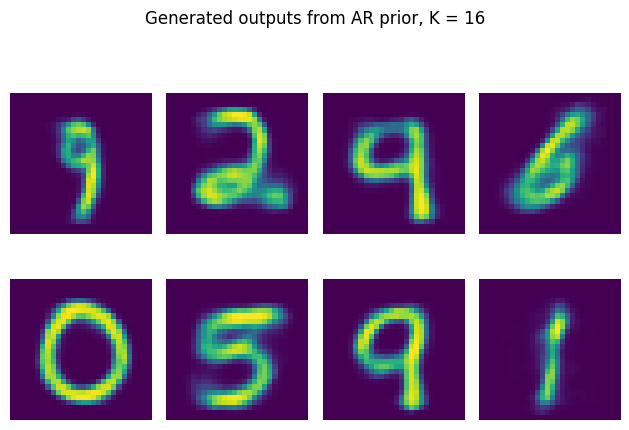

Epoch: 28, val nll=11.9251


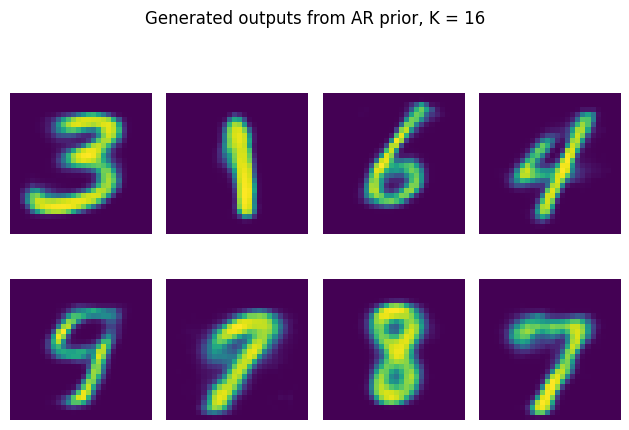

Epoch: 29, val nll=11.9948


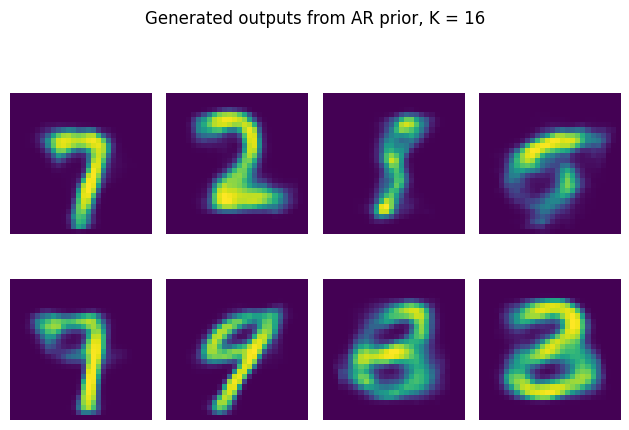

Epoch: 30, val nll=11.9712


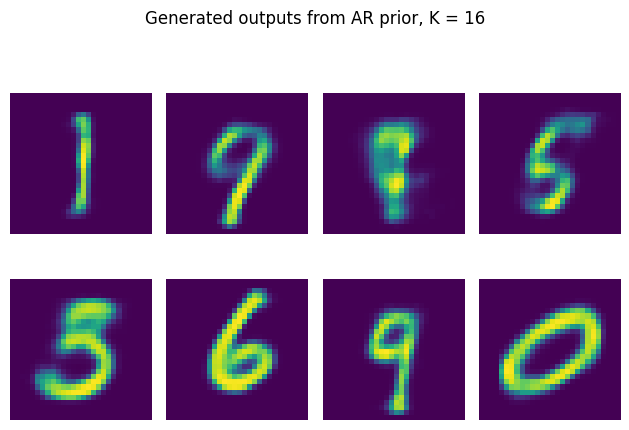

Epoch: 31, val nll=11.8875


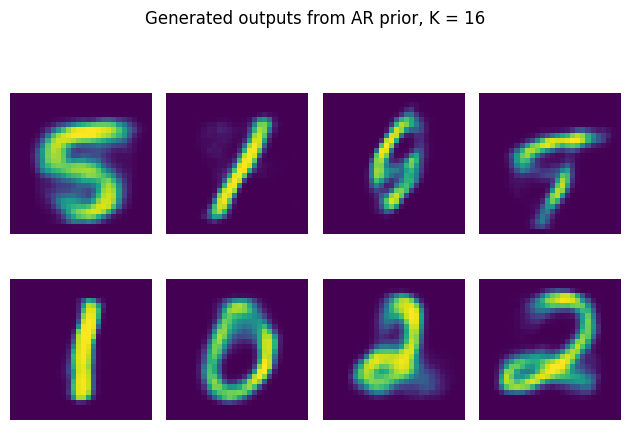

Epoch: 32, val nll=11.9497


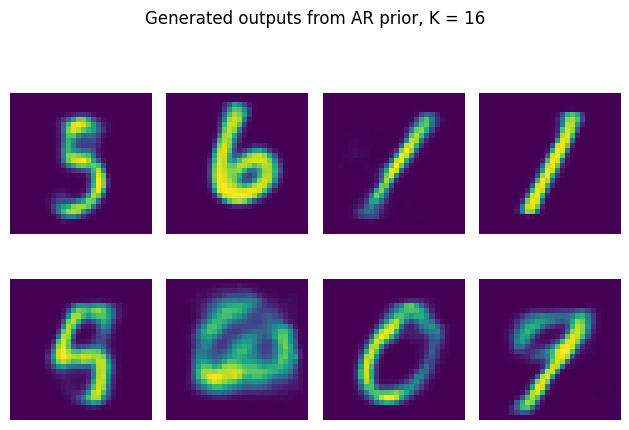

Epoch: 33, val nll=11.9338


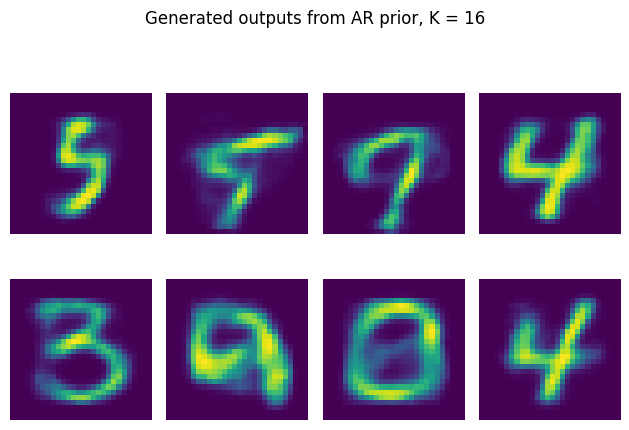

Epoch: 34, val nll=11.9011


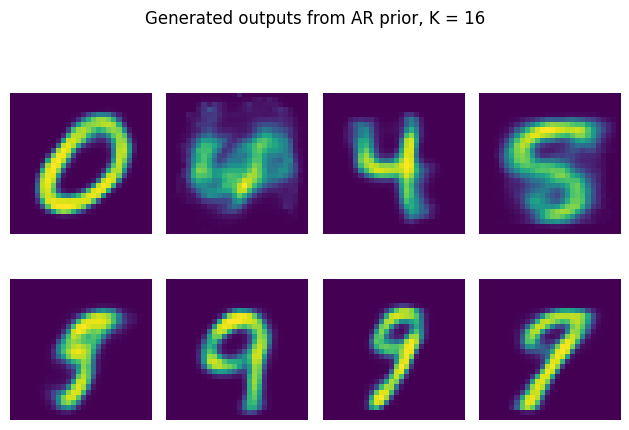

Epoch: 35, val nll=11.8800


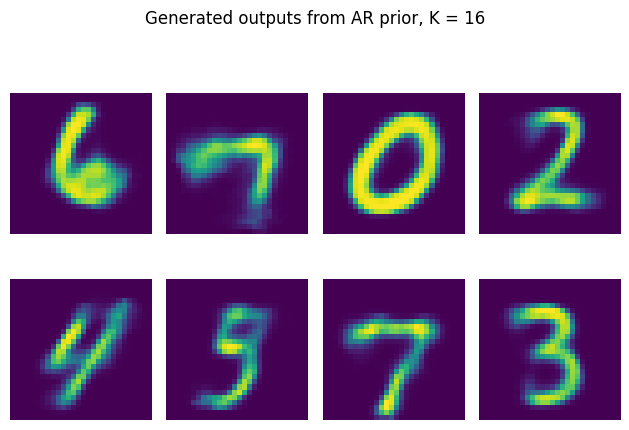

Epoch: 36, val nll=11.8618


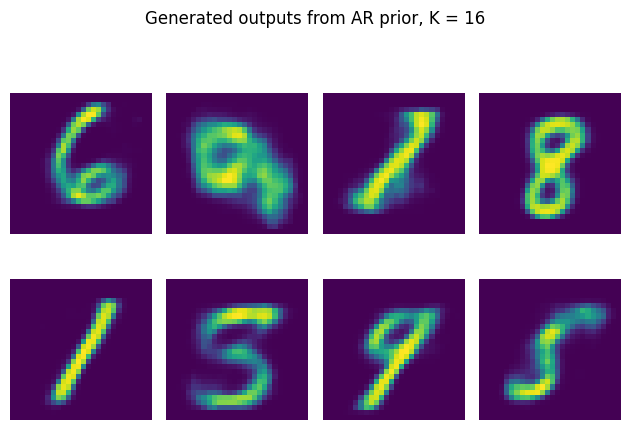

Epoch: 37, val nll=11.8818


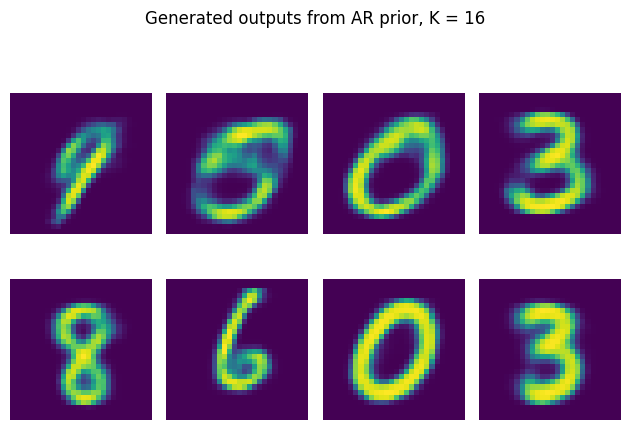

Epoch: 38, val nll=11.9746


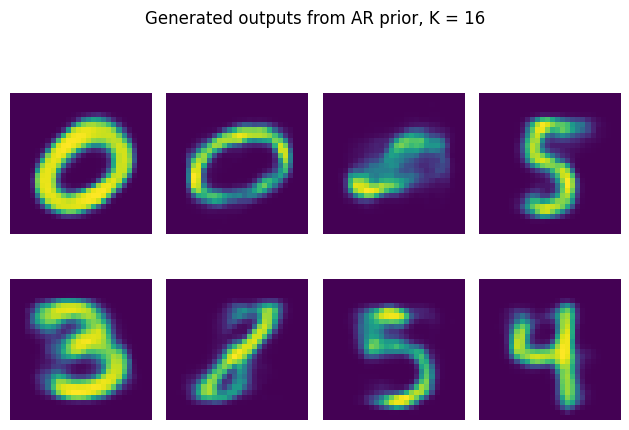

Epoch: 39, val nll=11.8660


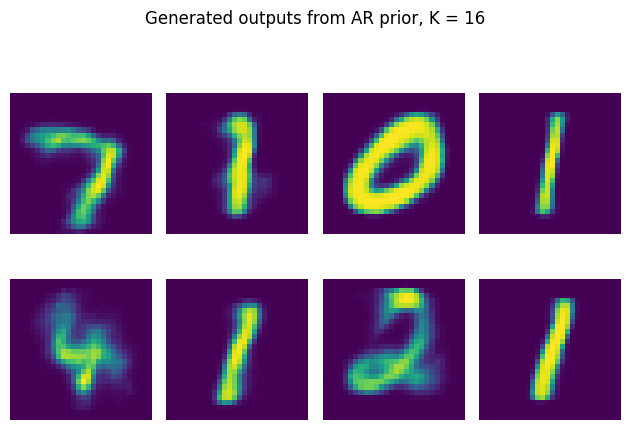

In [17]:
for p in vqvae.parameters():
    p.requires_grad = False
vqvae.eval()

arm_hdim = 128    # hidden layer dimensionality for AR prior
kernel = 3        # causal conv kernel size
lr_arm = 1e-3
num_epochs_arm = 40#150

prior_net = nn.Sequential(
    CausalConv1d(in_channels=1, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=True),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=False),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=arm_hdim, dilation=1, kernel_size=kernel, A=False),
    nn.LeakyReLU(),
    CausalConv1d(in_channels=arm_hdim, out_channels=K, dilation=1, kernel_size=kernel, A=False)
)

ar_prior = ARPrior(prior_net, num_latents=num_latents, K=K)

optimizer_arm = torch.optim.Adam([p for p in ar_prior.parameters() if p.requires_grad == True], lr=lr_arm)

nll_prior = training_ar_prior(name=result_dir + name, num_epochs=num_epochs_arm, vqvae=vqvae,
                              ar_prior=ar_prior, optimizer=optimizer_arm,
                              training_loader=training_loader, val_loader=val_loader)

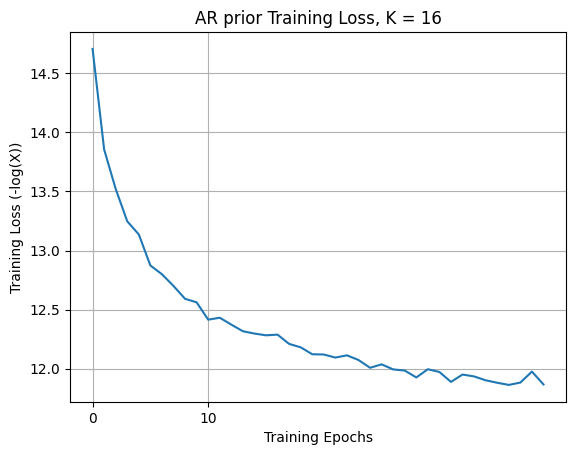

In [18]:
# TODO: Visualize autoregressive prior model training process
# NLL loss over full trianing

fig = plt.figure()
plt.plot(nll_prior)
plt.xlabel("Training Epochs")
plt.ylabel("Training Loss (-log(X))")
plt.title(f"AR prior Training Loss, K = {K}")
plt.xticks(np.arange(0,num_epochs_vqvae,10))
plt.grid()
plt.show()
fig.savefig(plot_folder+f"ar_prior_train_loss_{K}.png")



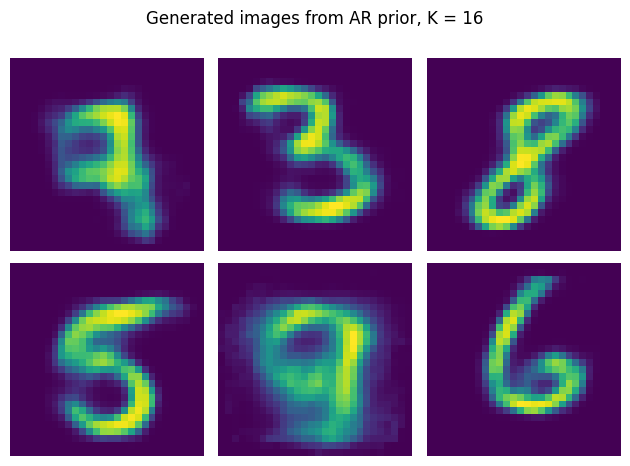

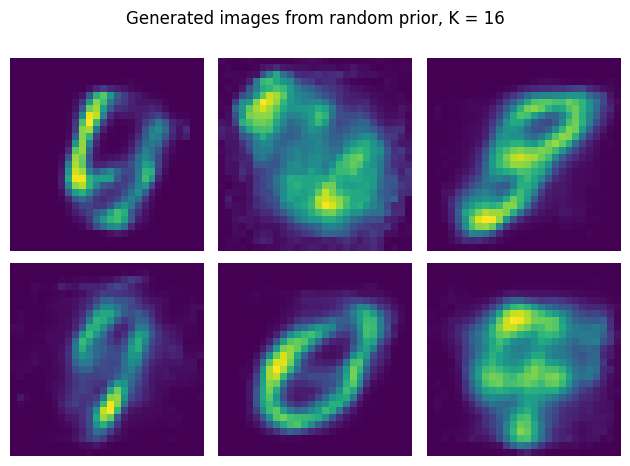

In [19]:
# TODO: Generate final samples from the full model.
# Sample index sequences from the AR prior, then decode with the frozen VQ-VAE decoder.

num_samples = 6
sampled_indices = ar_prior.sample(num_samples)
output_samples = vqvae.decode_indices(sampled_indices)

reconstructed_images = output_samples.reshape(-1,image_dim, image_dim).detach().numpy()

# TODO: Visualize the final samples from the full model.
fig, axs = plt.subplots(int(np.ceil(num_samples/3)),3,layout = "tight")
for i in range(int(np.ceil(num_samples/3))):
    for j in range(3):
        axs[i][j].imshow(reconstructed_images[i*3+j])
        axs[i][j].axis("off")
plt.suptitle(f"Generated images from AR prior, K = {K}")
plt.show()
fig.savefig(plot_folder+f"ar_prior_generations_{K}.png")


#ADDITIONAL: generation with randomly drawn indices, no prior
random_indices = torch.randint(0, K, (num_samples, num_latents))
random_output = vqvae.decode_indices(random_indices)

random_reconstructions = random_output.reshape(-1, 28, 28)
fig, axs = plt.subplots(int(np.ceil(num_samples/3)),3,layout = "tight")
for i in range(int(np.ceil(num_samples/3))):
    for j in range(3):
        axs[i][j].imshow(random_reconstructions[i*3+j])
        axs[i][j].axis("off")
plt.suptitle(f"Generated images from random prior, K = {K}")
plt.show()
fig.savefig(plot_folder+f"random_generations_{K}.png")

